# Inicialização de pesos em redes neuriais

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
tf.__version__

'2.19.0'

## Inicializadores

* https://keras.io/api/layers/initializers/

In [2]:
from tensorflow.keras import initializers

## Random normal

In [4]:
normal = initializers.RandomNormal(mean=0.0, stddev=0.05, seed=None)
dados_normal = normal(shape=[1000])

In [8]:
np.mean(dados_normal), np.std(dados_normal)

(np.float32(-0.0007765277), np.float32(0.05223759))

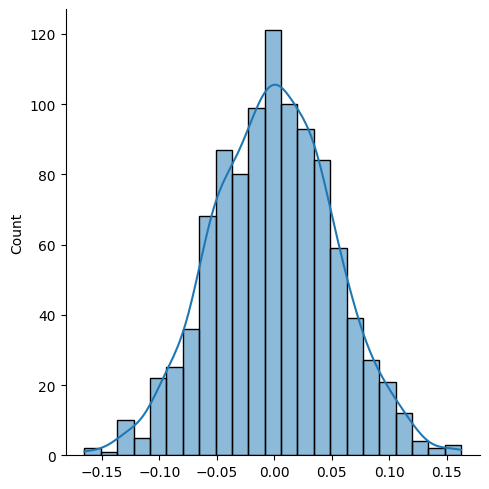

In [12]:
sns.displot(dados_normal, kde=True)
plt.show()

## Random uniform

In [13]:
uniforme = initializers.RandomUniform(minval=-0.05, maxval=0.05, seed=None)
dados_uniforme = uniforme(shape=[1000])

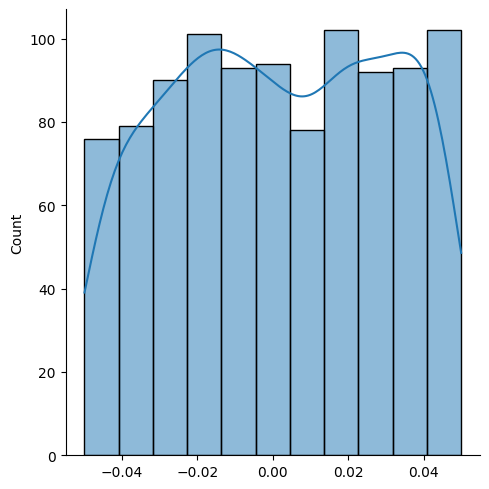

In [14]:
sns.displot(dados_uniforme, kde=True)
plt.show()

### Glorot normal (Xavier initialization)

* Centered on 0 with stddev = sqrt(2/ (fan_in + fan_out)) where fan_in is the number of input units in the weight tensor and fan_out is the number of output  units of output units in the weight tensor
* https://keras.io/api/layers/initializers/

In [17]:
normal_glorot = initializers.GlorotNormal(seed=None)
dados_normal_glorot = normal_glorot(shape=[1000])

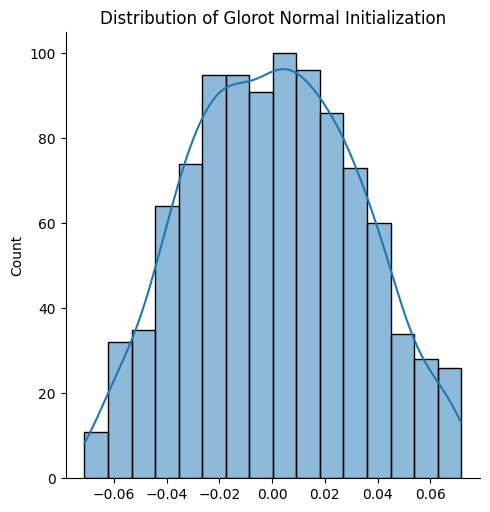

In [19]:
sns.displot(dados_normal_glorot, kde=True)
plt.title('Distribution of Glorot Normal Initialization')
plt.show()

## Glorot Uniform

In [15]:
glorot_uniform = initializers.GlorotUniform(seed=None)
dados_glorot_uniforme = glorot_uniform(shape=[1000, 1000])
print(f"Glorot Uniform - Mean: {np.mean(dados_glorot_uniforme):.4f}, Std: {np.std(dados_glorot_uniforme):.4f}")

Glorot Uniform - Mean: 0.0000, Std: 0.0316


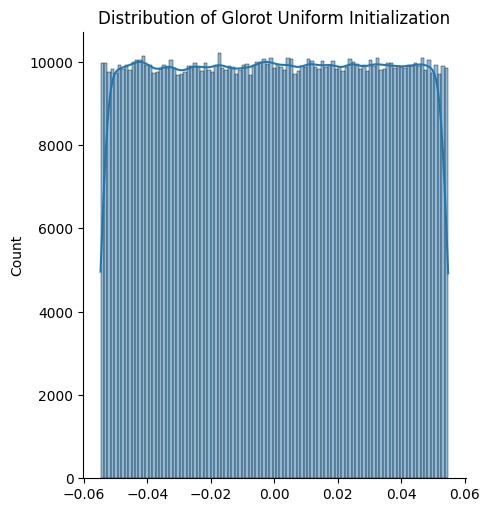

In [16]:
sns.displot(dados_glorot_uniforme.numpy().flatten(), kde=True)
plt.title('Distribution of Glorot Uniform Initialization')
plt.show()

### Quando usar cada tipo de inicialização de pesos:

**1. Random Normal (Inicialização Normal Aleatória):**
*   **Descrição:** Os pesos são amostrados de uma distribuição normal (gaussiana) com média e desvio padrão especificados. No exemplo, `mean=0.0` e `stddev=0.05`.
*   **Quando usar:**
    *   É uma das inicializações mais básicas e pode ser um bom ponto de partida para redes pequenas ou simples.
    *   Pode ser útil quando você tem certeza de que os gradientes não explodirão nem desaparecerão facilmente.
    *   No entanto, com redes neurais mais profundas ou funções de ativação como sigmoid/tanh, pode levar a problemas de gradiente (vanishing/exploding) se o desvio padrão não for ajustado corretamente.

**2. Random Uniform (Inicialização Uniforme Aleatória):**
*   **Descrição:** Os pesos são amostrados uniformemente de um intervalo `[minval, maxval]`. No seu exemplo, `minval=-0.05` e `maxval=0.05`.
*   **Quando usar:**
    *   Similar à inicialização normal aleatória, é simples e pode funcionar para redes pequenas.
    *   Pode ser preferível em alguns casos onde se deseja garantir que os pesos estejam dentro de um limite estrito desde o início.
    *   Assim como a normal, pode sofrer com problemas de gradiente em redes mais profundas sem os devidos ajustes de escala.

**3. Glorot Normal (Xavier Initialization):**
*   **Descrição:** Os pesos são amostrados de uma distribuição normal truncada centrada em 0. O desvio padrão é calculado com base no número de neurônios de entrada (`fan_in`) e saída (`fan_out`) da camada: `stddev = sqrt(2 / (fan_in + fan_out))`.
*   **Quando usar:**
    *   **Recomendado para camadas com funções de ativação Sigmoid ou Tanh.**
    *   A principal vantagem é que ele tenta manter a variância das ativações das camadas e dos gradientes aproximadamente constante em toda a rede. Isso ajuda a mitigar os problemas de vanishing/exploding gradients, permitindo que a rede treine de forma mais eficaz e generalize melhor.
    *   É um bom `default` para muitas arquiteturas de redes neurais com as funções de ativação mencionadas.

**4. Glorot Uniform (Xavier Initialization - Uniforme):**
*   **Descrição:** Similar ao Glorot Normal, mas os pesos são amostrados de uma distribuição uniforme `[-limit, limit]`, onde `limit = sqrt(6 / (fan_in + fan_out))`.
*   **Quando usar:**
    *   **Recomendado para camadas com funções de ativação Sigmoid ou Tanh.**
    *   Oferece os mesmos benefícios que a Glorot Normal em termos de manutenção da variância das ativações e gradientes, mas usa uma distribuição uniforme em vez de normal.
    *   A escolha entre Glorot Normal e Glorot Uniform geralmente não é crítica e muitas vezes se resume a preferência ou o que funciona ligeiramente melhor para um problema específico. Ambos são eficazes para as mesmas funções de ativação.

### Considerações Gerais:

*   **ReLU e Variantes (Leaky ReLU, ELU):** Para camadas com ativações ReLU e suas variantes, **He initialization** (He Normal ou He Uniform) é geralmente preferida sobre Glorot. He initialization usa `stddev = sqrt(2 / fan_in)` (ou `limit = sqrt(6 / fan_in)` para uniforme), que é mais adequada para o comportamento da ReLU. Embora Glorot possa funcionar, He tende a ser mais robusto para essas ativações.
*   **Redes Profundas:** Inicializadores como Glorot e He são cruciais para treinar redes neurais profundas de forma eficaz, pois ajudam a propagar informações e gradientes através de muitas camadas.
*   **Experimentação:** A melhor inicialização de pesos pode variar dependendo da arquitetura da rede, da função de ativação, do conjunto de dados e do problema. É sempre uma boa prática experimentar diferentes inicializadores para encontrar o que funciona melhor.